In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import os

In [2]:
def load_df(dir_path):
    grads_path = os.path.join(dir_path, [f for f in os.listdir(dir_path) if f.startswith("grad_")][0])
    dist_path = os.path.join(dir_path, [f for f in os.listdir(dir_path) if f.startswith("cosine_")][0])
    grads_df = pd.read_csv(grads_path)
    dist_df = pd.read_csv(dist_path)

    return grads_df, dist_df

In [3]:
# grads_path = "/raid/s3/opengptx/behzad_shomali/instruction_tuning/pretrained_llama/block__8_11__3/2025_10_27-18_32_46/diagnostic/grad_2025-10-27_18-32-55.csv"
# dist_path = "/raid/s3/opengptx/behzad_shomali/instruction_tuning/pretrained_llama/block__8_11__3/2025_10_27-18_32_46/diagnostic/cosine_2025-10-27_18-32-55.csv"

# grads_path = "/raid/s3/opengptx/behzad_shomali/instruction_tuning/pretrained_llama/block__8_11__5/2025_10_29-13_00_36/diagnostic/grad_2025-10-29_13-00-43.csv"
# dist_path = "/raid/s3/opengptx/behzad_shomali/instruction_tuning/pretrained_llama/block__8_11__5/2025_10_29-13_00_36/diagnostic/cosine_2025-10-29_13-00-43.csv"

# grads_path = "/raid/s3/opengptx/behzad_shomali/instruction_tuning/pretrained_llama/baseline/2025_10_29-13_52_27/diagnostic/grad_2025-10-29_13-52-35.csv"
# dist_path = "/raid/s3/opengptx/behzad_shomali/instruction_tuning/pretrained_llama/baseline/2025_10_29-13_52_27/diagnostic/cosine_2025-10-29_13-52-35.csv"

# grads_path = "/raid/s3/opengptx/behzad_shomali/instruction_tuning/pretrained_llama/block__8_11__5/2025_11_08-15_57_27/diagnostic/grad_2025-11-08_15-57-51.csv"
# dist_path = "/raid/s3/opengptx/behzad_shomali/instruction_tuning/pretrained_llama/block__8_11__5/2025_11_08-15_57_27/diagnostic/cosine_2025-11-08_15-57-51.csv"

# grads_path = "/raid/s3/opengptx/behzad_shomali/instruction_tuning/pretrained_llama/baseline/2025_11_10-09_18_11/diagnostic/grad_2025-11-10_09-18-34.csv"
# dist_path = "/raid/s3/opengptx/behzad_shomali/instruction_tuning/pretrained_llama/baseline/2025_11_10-09_18_11/diagnostic/cosine_2025-11-10_09-18-34.csv"


In [4]:
# grads_df = pd.read_csv(grads_path)
# dist_df = pd.read_csv(dist_path)

path = "/raid/s3/opengptx/behzad_shomali/instruction_tuning/pretrained_llama/block__11_12__3/2025_11_11-16_38_46/diagnostic"
grads_df, dist_df = load_df(path)

In [5]:
print(grads_df.shape)
grads_df.head(100)

(2170027, 10)


,global_step,step,layer,layer_name,is_recurrent,iteration,norm,mean,max,std
0,0,0,0,NaN,False,0,0.000000,0.000000,0.000000,0.000000
1,20,0,-100,model.norm.weight,False,0,0.010986,-0.000024,0.001984,0.000242
2,20,1,14,model.layers.14.mlp.down_proj.weight,False,0,0.917969,-0.000000,0.018921,0.000224
3,20,2,14,model.layers.14.mlp.up_proj.weight,False,0,0.464844,-0.000000,0.027832,0.000113
4,20,3,14,model.layers.14.mlp.gate_proj.weight,False,0,0.296875,0.000000,0.009033,0.000072
...,...,...,...,...,...,...,...,...,...,...
95,20,94,5,model.layers.5.mlp.up_proj.weight,False,0,0.667969,-0.000000,0.008240,0.000163
96,20,95,5,model.layers.5.mlp.gate_proj.weight,False,0,0.382812,0.000000,0.009521,0.000093
97,20,96,5,model.layers.5.post_attention_layernorm.weight,False,0,0.041748,-0.000064,0.010376,0.000919
98,20,97,5,model.layers.5.self_attn.o_proj.weight,False,0,0.792969,0.000000,0.013916,0.000387


In [6]:
print(dist_df.shape)
dist_df.head()

(28500, 6)


,global_step,iteration,mean,min,max,std
0,20,0,0.812295,0.511780,0.999914,0.062343
1,20,0,0.787124,0.483980,0.999914,0.075148
2,20,0,0.809608,0.480170,0.999914,0.067112
3,20,0,0.807719,0.468068,0.999914,0.069020
4,20,0,0.804393,0.465093,0.999914,0.072040


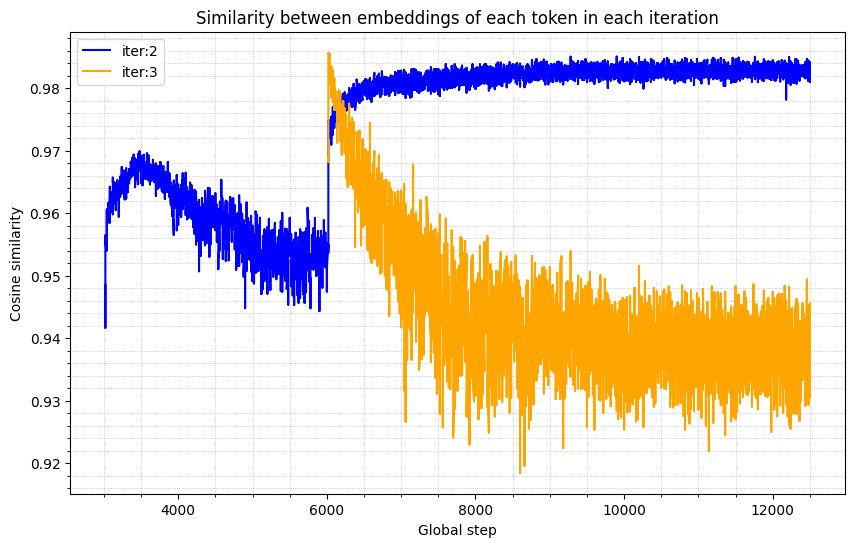

In [7]:
fig, ax = plt.subplots(1, 1, figsize=(10,6))

colors = ["black", "blue", "orange", "pink", "green"]
for iter in dist_df['iteration'].unique():
    if iter == 0:
        continue
    dist_sub_df = dist_df[dist_df["iteration"] == iter]
    ax.plot(dist_sub_df["global_step"], dist_sub_df["mean"], label=f"iter:{iter+1}", color=colors[iter])
    ax.set_xlabel("Global step")
    ax.set_ylabel("Cosine similarity")
    ax.minorticks_on()
    ax.grid(True, which='minor', linestyle=':', linewidth=0.5)

plt.title("Similarity between embeddings of each token in each iteration")
plt.legend()

## Grad

In [8]:
def extract_base_layer(name: str) -> str:
    parts = name.split(".")
    # keep up to a consistent depth
    # adjust depending on your structure
    # print(parts)
    if len(parts) >= 5:
        
        if parts[3] == "layer_block":
            return ".".join(parts[:5])
        return ".".join(parts[:3])
    else:
        return name

In [9]:
grads_df["layer_name"] = grads_df["layer_name"].astype(str)
grads_df

,global_step,step,layer,layer_name,is_recurrent,iteration,norm,mean,max,std
0,20,0,-100,model.norm.weight,False,0,0.011017,-0.000024,0.001967,0.000242
1,20,1,12,model.layers.12.mlp.down_proj.weight,False,0,0.919036,-0.000000,0.018921,0.000224
2,20,2,12,model.layers.12.mlp.up_proj.weight,False,0,0.464816,-0.000000,0.027588,0.000113
3,20,3,12,model.layers.12.mlp.gate_proj.weight,False,0,0.297877,0.000000,0.008911,0.000073
4,20,4,12,model.layers.12.post_attention_layernorm.weight,False,0,0.105787,0.000306,0.093718,0.002318
...,...,...,...,...,...,...,...,...,...,...
170795,680,170795,0,model.layers.0.self_attn.v_proj.weight,False,0,0.609685,0.000000,0.052490,0.000595
170796,680,170796,0,model.layers.0.self_attn.k_proj.weight,False,0,0.048166,0.000000,0.004364,0.000047
170797,680,170797,0,model.layers.0.self_attn.q_proj.weight,False,0,0.033109,-0.000000,0.001114,0.000016
170798,680,170798,0,model.layers.0.input_layernorm.weight,False,0,0.020762,0.000001,0.002435,0.000459


In [10]:
grads_df["base_layer"] = grads_df["layer_name"].apply(extract_base_layer)
grads_df["base_layer"]

0                 model.norm.weight
1                   model.layers.12
2                   model.layers.12
3                   model.layers.12
4                   model.layers.12
                    ...            
170795               model.layers.0
170796               model.layers.0
170797               model.layers.0
170798               model.layers.0
170799    model.embed_tokens.weight
Name: base_layer, Length: 170800, dtype: object

In [11]:
grads_df.dropna()

,global_step,step,layer,layer_name,is_recurrent,iteration,norm,mean,max,std,base_layer
0,20,0,-100,model.norm.weight,False,0,0.011017,-0.000024,0.001967,0.000242,model.norm.weight
1,20,1,12,model.layers.12.mlp.down_proj.weight,False,0,0.919036,-0.000000,0.018921,0.000224,model.layers.12
2,20,2,12,model.layers.12.mlp.up_proj.weight,False,0,0.464816,-0.000000,0.027588,0.000113,model.layers.12
3,20,3,12,model.layers.12.mlp.gate_proj.weight,False,0,0.297877,0.000000,0.008911,0.000073,model.layers.12
4,20,4,12,model.layers.12.post_attention_layernorm.weight,False,0,0.105787,0.000306,0.093718,0.002318,model.layers.12
...,...,...,...,...,...,...,...,...,...,...,...
170795,680,170795,0,model.layers.0.self_attn.v_proj.weight,False,0,0.609685,0.000000,0.052490,0.000595,model.layers.0
170796,680,170796,0,model.layers.0.self_attn.k_proj.weight,False,0,0.048166,0.000000,0.004364,0.000047,model.layers.0
170797,680,170797,0,model.layers.0.self_attn.q_proj.weight,False,0,0.033109,-0.000000,0.001114,0.000016,model.layers.0
170798,680,170798,0,model.layers.0.input_layernorm.weight,False,0,0.020762,0.000001,0.002435,0.000459,model.layers.0


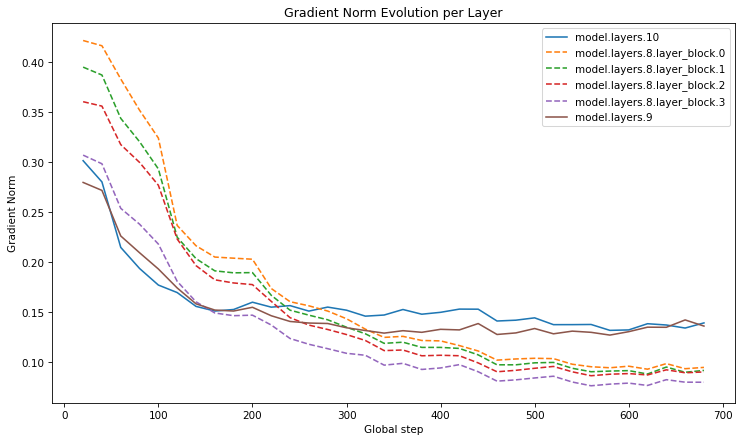

In [12]:
grads_df = grads_df.replace(["NaN", "None", "nan", ""], pd.NA)
filtered_df = grads_df.dropna()

# Optionally remove invalid steps
# df = df[df["step"] != -100].copy()

# If 'step' column is broken, use index instead
filtered_df["step"] = filtered_df.index

# --- Plot gradient norm evolution per layer ---
plt.figure(figsize=(10, 6), dpi=75)

beg_limit = 0
end_limit = 10000
groups_to_show = [
    # "model.layers.6",
    # "model.layers.7",
    "model.layers.8",
    "model.layers.9",
    "model.layers.10"
]
for layer_name, group in filtered_df.groupby("base_layer"):
    if "weight" in layer_name or not any(g in layer_name for g in groups_to_show):
        continue
    # group = group[group["step"] <= end_limit]
    # group = group[beg_limit <= group["step"]]
    group = group[["step", "norm", "global_step", "base_layer", "iteration"]].groupby(['global_step', 'base_layer']).mean().reset_index()
    if "layer_block" in layer_name:
        plt.plot(group["global_step"], group["norm"], label=f"{layer_name}", linestyle='--')
    else:
        plt.plot(group["global_step"], group["norm"], label=f"{layer_name}")

# plt.yscale("log")
plt.xlabel("Global step")
plt.ylabel("Gradient Norm")
plt.title("Gradient Norm Evolution per Layer")
plt.legend()
plt.tight_layout()
plt.show()

In [19]:
filtered_df["iteration"].value_counts()

iteration
0    163920
1      2320
2      1920
3      1520
4      1120
Name: count, dtype: int64

In [25]:
group

,global_step,step,layer,layer_name,is_recurrent,iteration,norm,mean,max,std,base_layer
84037,420,84037,0,recursive_block_layer_3,True,4,0.035151,-0.0,0.000816,0.000012,recursive_block_layer_3
84347,420,84347,0,recursive_block_layer_3,True,4,0.032726,0.0,0.000706,0.000009,recursive_block_layer_3
84657,420,84657,0,recursive_block_layer_3,True,4,0.027898,-0.0,0.000714,0.000007,recursive_block_layer_3
84967,420,84967,0,recursive_block_layer_3,True,4,0.026428,0.0,0.001001,0.000007,recursive_block_layer_3
85277,420,85277,0,recursive_block_layer_3,True,4,0.027389,-0.0,0.000780,0.000007,recursive_block_layer_3
...,...,...,...,...,...,...,...,...,...,...,...
169287,680,169287,0,recursive_block_layer_3,True,4,0.027645,-0.0,0.000598,0.000008,recursive_block_layer_3
169597,680,169597,0,recursive_block_layer_3,True,4,0.031584,0.0,0.000652,0.000010,recursive_block_layer_3
169907,680,169907,0,recursive_block_layer_3,True,4,0.033799,-0.0,0.000649,0.000008,recursive_block_layer_3
170217,680,170217,0,recursive_block_layer_3,True,4,0.032138,-0.0,0.000563,0.000009,recursive_block_layer_3


In [29]:
iter_df

,global_step,step,layer,layer_name,is_recurrent,iteration,norm,mean,max,std,base_layer
84037,420,84037,0,recursive_block_layer_3,True,4,0.035151,-0.0,0.000816,0.000012,recursive_block_layer_3
84047,420,84047,0,recursive_block_layer_2,True,4,0.035108,-0.0,0.000769,0.000012,recursive_block_layer_2
84057,420,84057,0,recursive_block_layer_1,True,4,0.033567,-0.0,0.000726,0.000011,recursive_block_layer_1
84067,420,84067,0,recursive_block_layer_0,True,4,0.031445,-0.0,0.000696,0.000011,recursive_block_layer_0
84347,420,84347,0,recursive_block_layer_3,True,4,0.032726,0.0,0.000706,0.000009,recursive_block_layer_3
...,...,...,...,...,...,...,...,...,...,...,...
170247,680,170247,0,recursive_block_layer_0,True,4,0.030002,-0.0,0.000512,0.000008,recursive_block_layer_0
170527,680,170527,0,recursive_block_layer_3,True,4,0.033076,0.0,0.000601,0.000009,recursive_block_layer_3
170537,680,170537,0,recursive_block_layer_2,True,4,0.033984,0.0,0.000536,0.000010,recursive_block_layer_2
170547,680,170547,0,recursive_block_layer_1,True,4,0.032793,0.0,0.000534,0.000009,recursive_block_layer_1


In [30]:
group

,global_step,step,layer,layer_name,is_recurrent,iteration,norm,mean,max,std,base_layer
84037,420,84037,0,recursive_block_layer_3,True,4,0.035151,-0.0,0.000816,0.000012,recursive_block_layer_3
84347,420,84347,0,recursive_block_layer_3,True,4,0.032726,0.0,0.000706,0.000009,recursive_block_layer_3
84657,420,84657,0,recursive_block_layer_3,True,4,0.027898,-0.0,0.000714,0.000007,recursive_block_layer_3
84967,420,84967,0,recursive_block_layer_3,True,4,0.026428,0.0,0.001001,0.000007,recursive_block_layer_3
85277,420,85277,0,recursive_block_layer_3,True,4,0.027389,-0.0,0.000780,0.000007,recursive_block_layer_3
...,...,...,...,...,...,...,...,...,...,...,...
169287,680,169287,0,recursive_block_layer_3,True,4,0.027645,-0.0,0.000598,0.000008,recursive_block_layer_3
169597,680,169597,0,recursive_block_layer_3,True,4,0.031584,0.0,0.000652,0.000010,recursive_block_layer_3
169907,680,169907,0,recursive_block_layer_3,True,4,0.033799,-0.0,0.000649,0.000008,recursive_block_layer_3
170217,680,170217,0,recursive_block_layer_3,True,4,0.032138,-0.0,0.000563,0.000009,recursive_block_layer_3


In [37]:
filtered_df

,global_step,step,layer,layer_name,is_recurrent,iteration,norm,mean,max,std,base_layer
0,20,0,-100,model.norm.weight,False,0,0.011017,-0.000024,0.001967,0.000242,model.norm.weight
1,20,1,12,model.layers.12.mlp.down_proj.weight,False,0,0.919036,-0.000000,0.018921,0.000224,model.layers.12
2,20,2,12,model.layers.12.mlp.up_proj.weight,False,0,0.464816,-0.000000,0.027588,0.000113,model.layers.12
3,20,3,12,model.layers.12.mlp.gate_proj.weight,False,0,0.297877,0.000000,0.008911,0.000073,model.layers.12
4,20,4,12,model.layers.12.post_attention_layernorm.weight,False,0,0.105787,0.000306,0.093718,0.002318,model.layers.12
...,...,...,...,...,...,...,...,...,...,...,...
170795,680,170795,0,model.layers.0.self_attn.v_proj.weight,False,0,0.609685,0.000000,0.052490,0.000595,model.layers.0
170796,680,170796,0,model.layers.0.self_attn.k_proj.weight,False,0,0.048166,0.000000,0.004364,0.000047,model.layers.0
170797,680,170797,0,model.layers.0.self_attn.q_proj.weight,False,0,0.033109,-0.000000,0.001114,0.000016,model.layers.0
170798,680,170798,0,model.layers.0.input_layernorm.weight,False,0,0.020762,0.000001,0.002435,0.000459,model.layers.0


In [38]:
filtered_df['iteration'].unique()

array([0, 1, 2, 3, 4])

/tmp/ipykernel_360863/253680080.py:44: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


<Figure size 750x450 with 0 Axes>

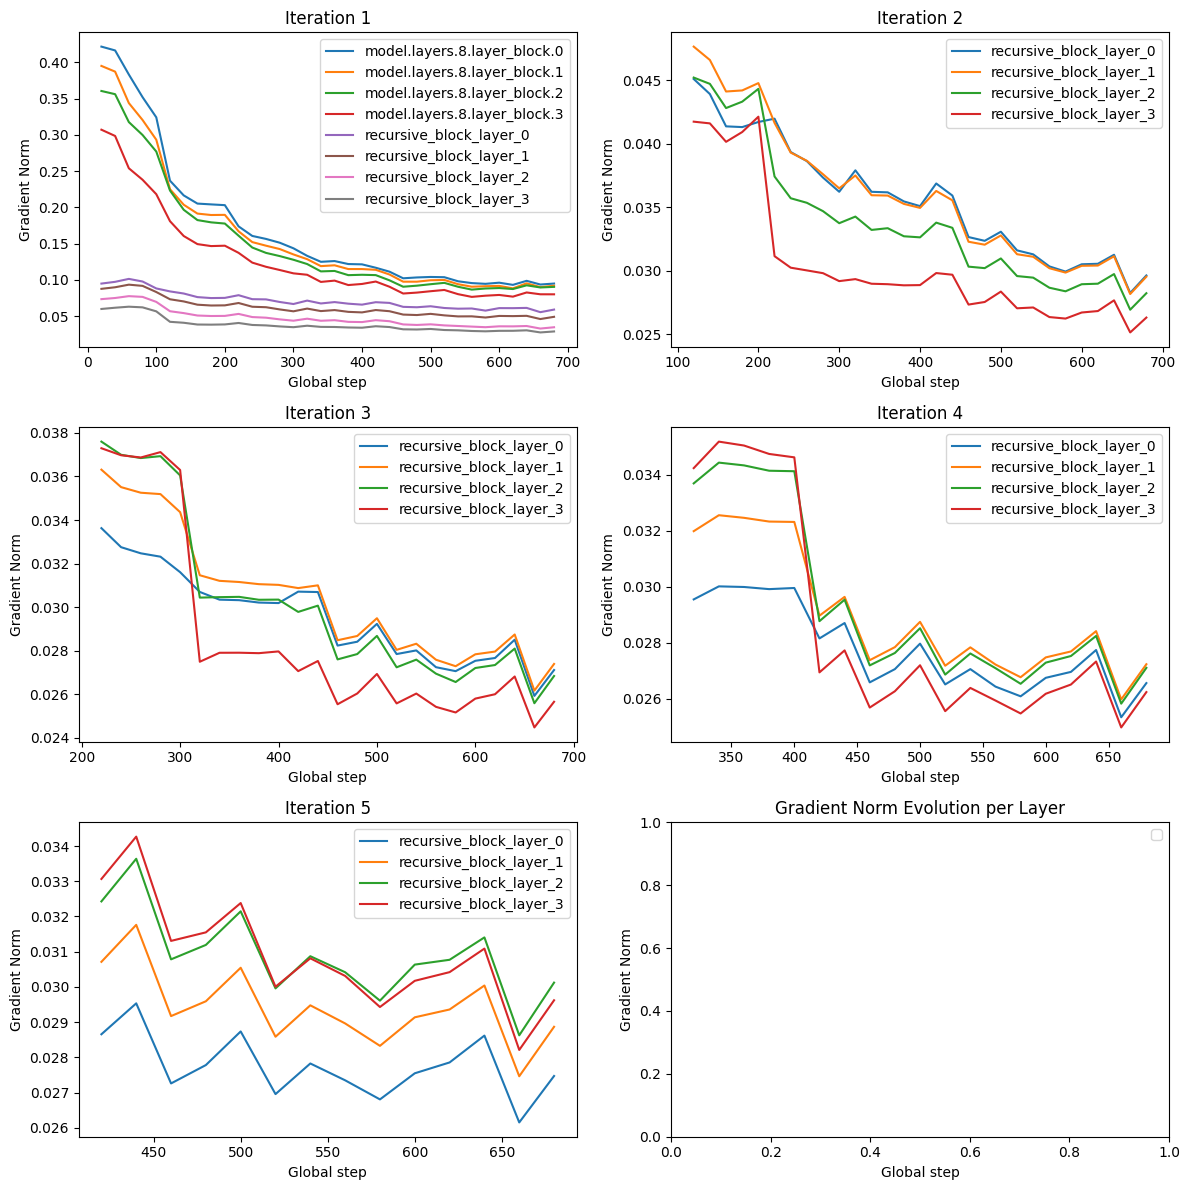

In [55]:
grads_df = grads_df.replace(["NaN", "None", "nan", ""], pd.NA)
filtered_df = grads_df.dropna()

# Optionally remove invalid steps
# df = df[df["step"] != -100].copy()

# If 'step' column is broken, use index instead
filtered_df["step"] = filtered_df.index

# --- Plot gradient norm evolution per layer ---
plt.figure(figsize=(10, 6), dpi=75)

beg_limit = 0
end_limit = 10000
groups_to_show = [
    "model.layers.8",
    "recursive_block_layer_0",
    "recursive_block_layer_1",
    "recursive_block_layer_2",
    "recursive_block_layer_3",
]

fig, axs = plt.subplots(3, 2, figsize=(12, 12))
axs = axs.flatten()
for iter in filtered_df['iteration'].unique():
    ax = axs[iter]
    iter_df = filtered_df[filtered_df["iteration"] == iter]
    for layer_name, group in iter_df.groupby("base_layer"):
        if "weight" in layer_name or not any(g in layer_name for g in groups_to_show):
            continue
        group = group[["step", "norm", "global_step", "base_layer", "iteration"]].groupby(['global_step', 'base_layer']).mean().reset_index()

        ax.plot(group["global_step"], group["norm"], label=f"{layer_name}")
    
    ax.set_title(f"Iteration {iter+1}")
    ax.set_xlabel("Global step")
    ax.set_ylabel("Gradient Norm")
    ax.legend()

# plt.yscale("log")
plt.xlabel("Global step")
plt.ylabel("Gradient Norm")
plt.title("Gradient Norm Evolution per Layer")
plt.legend()
plt.tight_layout()
plt.show()

In [15]:
group

,global_step,step,layer,layer_name,is_recurrent,iteration,norm,mean,max,std,base_layer
37,20,37,0,recursive_block_layer_3,True,0,0.049817,0.0,0.000877,0.000012,recursive_block_layer_3
187,20,187,0,recursive_block_layer_3,True,0,0.071716,0.0,0.001099,0.000025,recursive_block_layer_3
337,20,337,0,recursive_block_layer_3,True,0,0.066624,0.0,0.001519,0.000019,recursive_block_layer_3
487,20,487,0,recursive_block_layer_3,True,0,0.057133,0.0,0.001276,0.000014,recursive_block_layer_3
637,20,637,0,recursive_block_layer_3,True,0,0.059232,0.0,0.000697,0.000015,recursive_block_layer_3
...,...,...,...,...,...,...,...,...,...,...,...
170527,680,170527,0,recursive_block_layer_3,True,4,0.033076,0.0,0.000601,0.000009,recursive_block_layer_3
170567,680,170567,0,recursive_block_layer_3,True,3,0.029888,0.0,0.000522,0.000009,recursive_block_layer_3
170607,680,170607,0,recursive_block_layer_3,True,2,0.029393,0.0,0.000521,0.000008,recursive_block_layer_3
170647,680,170647,0,recursive_block_layer_3,True,1,0.030129,0.0,0.000636,0.000009,recursive_block_layer_3


In [107]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.animation import PillowWriter
import numpy as np

# Data preprocessing
grads_df = grads_df.replace(["NaN", "None", "nan", ""], pd.NA)
filtered_df = grads_df.dropna()
filtered_df["step"] = filtered_df.index

# Configuration
window_size = 4000
beg_limit = 0
end_limit = int(filtered_df["step"].max())
groups_to_show = ["model.layers.8"]

# Filter and prepare data
plot_data = {}
for layer_name, group in filtered_df.groupby("base_layer"):
    if "weight" in layer_name:# or not any(g in layer_name for g in groups_to_show):
        continue
    group = group[group["step"] <= end_limit]
    group = group[beg_limit <= group["step"]]
    if len(group) > 0:
        plot_data[layer_name] = group.sort_values("step")

# Get sorted layer names
layer_names = sorted(plot_data.keys())
n_layers = len(layer_names)

# Determine window positions
min_step = beg_limit
max_step = end_limit
window_starts = range(min_step, max_step - window_size + 1, 2000)  # Step by 2000

# Create figure with subplots (4x4 grid for 16 layers)
n_rows = 4
n_cols = 4
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 16), dpi=75)
axes = axes.flatten()  # Flatten to 1D array for easier indexing

def animate(frame_idx):
    print(f"Index: {frame_idx}/{len(list(window_starts))}", end="\r")
    window_start = list(window_starts)[frame_idx]
    window_end = window_start + window_size
    
    # Clear all axes
    for ax in axes:
        ax.clear()
    
    # Plot each layer in its own subplot
    for idx, layer_name in enumerate(layer_names):
        if idx >= len(axes):
            break
            
        ax = axes[idx]
        group = plot_data[layer_name]
        windowed = group[(group["step"] >= window_start) & (group["step"] < window_end)]
        
        if len(windowed) > 0:
            ax.plot(windowed["step"][::8], windowed["norm"][::8], linewidth=1.5, color='C0')
        
        ax.set_yscale("log")
        ax.set_xlabel("Step", fontsize=9)
        ax.set_ylabel("Grad Norm", fontsize=9)
        ax.set_title(f"{layer_name}", fontsize=10, pad=5)
        ax.set_xlim(window_start, window_end)
        ax.grid(True, alpha=0.3)
        ax.tick_params(labelsize=8)
    
    # Hide unused subplots
    for idx in range(n_layers, len(axes)):
        axes[idx].axis('off')
    
    # Add overall title
    fig.suptitle(f"Gradient Norm Evolution (Window: {window_start}-{window_end})", 
                 fontsize=16, y=0.995)
    plt.tight_layout(rect=[0, 0, 1, 0.99])

# Create animation
anim = animation.FuncAnimation(fig, animate, frames=len(window_starts), 
                              interval=100, repeat=True)

# Save as GIF
writer = PillowWriter(fps=10)
output_path = "/raid/s3/opengptx/behzad_shomali/modalities/src/modalities/notebooks/figures/Llama_block__8_11__3/gradient_norm_evolution.gif"
anim.save(output_path, writer=writer)
plt.close()

print(f"\nGIF created successfully with {len(window_starts)} frames!")
print(f"Number of layers: {n_layers}")
print(f"Window size: {window_size} steps")
print(f"Range: {min_step} to {max_step}")
print(f"File saved as: {output_path}")

/tmp/ipykernel_432612/1039603091.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df["step"] = filtered_df.index


Index: 3989/3990
GIF created successfully with 3990 frames!
Number of layers: 16
Window size: 4000 steps
Range: 0 to 7982839
File saved as: /raid/s3/opengptx/behzad_shomali/modalities/src/modalities/notebooks/figures/Llama_block__8_11__3/gradient_norm_evolution.gif
